# This notebook contains scripts that generate figures of Clinical Variants experiment

In [2]:
import pandas as pd
# This result file has been generated by multiprocess_clinvar_analysis.py script.
# res_data = pd.read_csv("result_files/clinvar_analysis.csv")
res_data = pd.read_csv("same_idx_work/results_processed.csv").drop(columns=["Unnamed: 0"])
# class balancing:
total_benign = 30727
total_patho = 32000
benign_scaler = total_patho / total_benign
res_data["sibling_count"] = res_data["sibling_count"].astype(float)
res_data.loc[res_data["dataset"] == "Benign", "sibling_count"] = (
    res_data.loc[res_data["dataset"] == "Benign", "sibling_count"] * benign_scaler
)
res_data.head()

,dataset,matrix,sibling_count,data_size,vocab_size,config,is_pre
0,Benign,blosum62,1295.538126,30727,800,0.7_3_12_0,False
1,Benign,blosum62,5069.678133,30727,51200,0.7_3_12_0.1,False
2,Benign,blosum62,691.509096,30727,1600,0.8_3_12_0.2,False
3,Benign,blosum62,2677.514889,30727,51200,0.8_3_12_0.2,False
4,Benign,blosum62,432.193185,30727,800,0.8_3_12_0.005,False


In [3]:
res_data["family_rate"] = res_data["sibling_count"]/res_data["data_size"]
sib_rate = res_data.groupby(["dataset", "vocab_size"])["family_rate"]
same_sibling_data_mean = sib_rate.mean()
same_sibling_data_std = sib_rate.std()

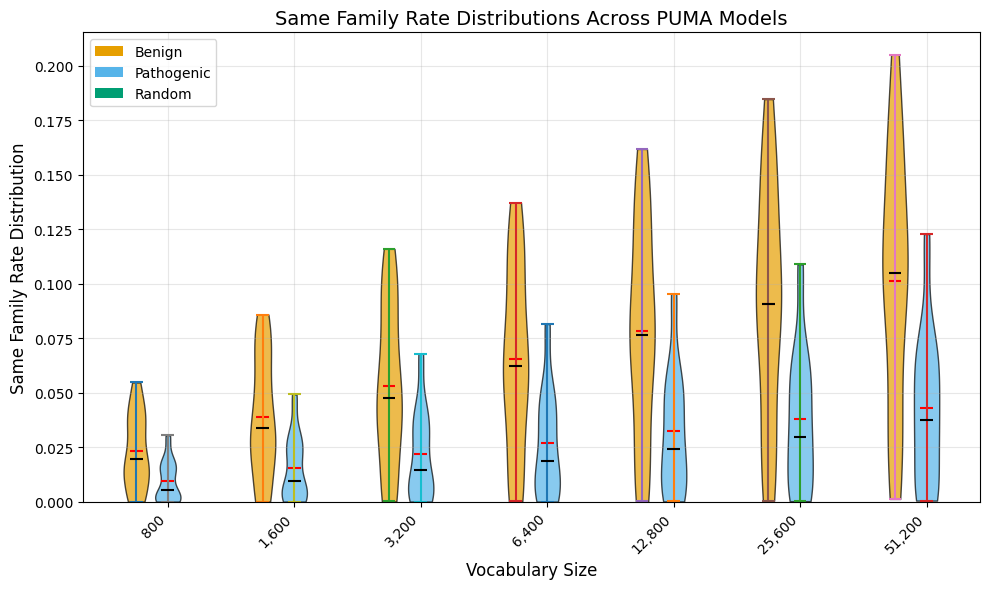

In [4]:
import matplotlib.pyplot as plt

# --- plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))


colors = {
    "Benign": "#E69F00", 
    "Pathogenic": "#56B4E9", 
    "Random": "#009E73",
}

datasets = ["Benign", "Pathogenic", "Random"]
offset = 0.25  # horizontal offset for separation
x_vals = sorted(res_data["vocab_size"].unique())

for i, ((dataset_str, ), group) in enumerate(res_data.groupby(["dataset"])):
    for j, ((v_size, ), final_group) in enumerate(group.groupby(["vocab_size"])):
        vals = final_group["family_rate"].values

        # plot violin, shifted for visibility
        parts = ax1.violinplot(
            vals,
            positions=[j + (i - 1) * offset],  # shift left/center/right
            widths=0.2,
            showmeans=True,
            showmedians=True,
        )
        # colorize
        for pc in parts['bodies']:
            pc.set_facecolor(colors[dataset_str])
            pc.set_edgecolor("black")
            pc.set_alpha(0.7)
        if 'cmedians' in parts:
            parts['cmedians'].set_color("black")
        if 'cmeans' in parts:
            parts['cmeans'].set_color("red")

# --- labels, legend, cosmetics ---
ax1.set_xticks(range(len(x_vals)))
ax1.set_xticklabels([f"{v:,}" for v in x_vals], rotation=45, ha="right")
ax1.set_xlabel("Vocabulary Size", fontsize=12)
ax1.set_ylabel("Same Family Rate Distribution", fontsize=12)
ax1.set_ylim(bottom=0)
ax1.set_title("Same Family Rate Distributions Across PUMA Models", fontsize=14)
ax1.grid(True, alpha=0.3)

# custom legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[d], label=d) for d in datasets]
ax1.legend(handles=legend_handles)

plt.tight_layout()
# plt.savefig("samesiblingrate.eps")
plt.show()
